In [2]:
import os 
import sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")
import params

In [3]:
# Load hydrophone positions
fpath = os.path.join(
    params.root_data, "hydro_positions", "hydrophones_estimated_positions.csv"
)

df_hydro_pos = pd.read_csv(fpath, index_col=0)

In [4]:
df_hydro_pos

,r,z
h_index,,
H1,-3.509175,4.104796
H2,-0.559483,3.969895
H3,2.396272,3.966405
H4,5.401467,3.917832
H5,-3.618455,1.418993


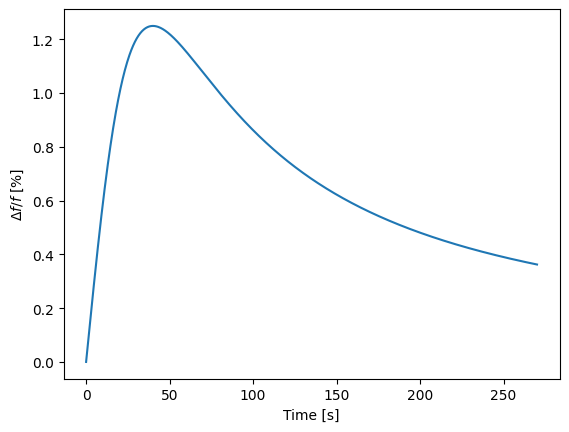

In [5]:
tmax = 270
t = np.linspace(0, tmax, int(1e3))
vs = 0.1    # m/s
rs = vs * t
c0 = 1500

# for h_idx in list(df_hydro_pos.index)[-1]:
#     # print(h_idx)
#     rh, zh = df_hydro_pos.loc[h_idx]
#     theta_h =
#     delta_f_doppler = vs / c0 * np.cos(theta)


# Cas d'un récepteur en (r=0, zh=4)
zh = 4
f0 = 1 # Fréquence centrale du chirp 
a = 1 / (1 - (vs/c0)**2)
b = 1 - (vs / c0) ** 2 * t / (
    (vs / c0) ** 2 * t**2 + (zh / c0) ** 2 * (1 - (vs / c0) ** 2)
)
# b = t
ft = f0 * a * b
delta_ft = (f0 - ft) / f0 * 100
plt.figure()
plt.plot(t, delta_ft)
plt.xlabel("Time [s]")
plt.ylabel(r"$\Delta f / f$ [%]")

img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization"
fpath = os.path.join(img_dir, "doppler_shift.png")
plt.savefig(fpath)